In [1]:
import pandas as pd

***Load Dataset***

In [2]:
df = pd.read_csv("insurance.csv")

***Disply dataset***

In [3]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


***Converting columns fronm string (sex, somker, region) to numerical value***

In [4]:
df['sex'].unique()

array(['female', 'male'], dtype=object)

In [5]:
df['sex']=df['sex'].map({'female':0,'male':1})

In [6]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,yes,southwest,16884.92400
1,18,1,33.770,1,no,southeast,1725.55230
2,28,1,33.000,3,no,southeast,4449.46200
3,33,1,22.705,0,no,northwest,21984.47061
4,32,1,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,1,30.970,3,no,northwest,10600.54830
1334,18,0,31.920,0,no,northeast,2205.98080
1335,18,0,36.850,0,no,southeast,1629.83350
1336,21,0,25.800,0,no,southwest,2007.94500


In [7]:
df['smoker']=df['smoker'].map({'yes':1,'no':0})

In [8]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,northwest,10600.54830
1334,18,0,31.920,0,0,northeast,2205.98080
1335,18,0,36.850,0,0,southeast,1629.83350
1336,21,0,25.800,0,0,southwest,2007.94500


In [15]:
df = df.join(pd.get_dummies(df.region,dtype=int)).drop('region',axis=1)

In [16]:
df

,age,sex,bmi,children,smoker,charges,northeast,northwest,southeast,southwest
0,19,0,27.900,0,1,16884.92400,0,0,0,1
1,18,1,33.770,1,0,1725.55230,0,0,1,0
2,28,1,33.000,3,0,4449.46200,0,0,1,0
3,33,1,22.705,0,0,21984.47061,0,1,0,0
4,32,1,28.880,0,0,3866.85520,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,10600.54830,0,1,0,0
1334,18,0,31.920,0,0,2205.98080,1,0,0,0
1335,18,0,36.850,0,0,1629.83350,0,0,1,0
1336,21,0,25.800,0,0,2007.94500,0,0,0,1


array([[<Axes: title={'center': 'age'}>, <Axes: title={'center': 'sex'}>,
        <Axes: title={'center': 'bmi'}>],
       [<Axes: title={'center': 'children'}>,
        <Axes: title={'center': 'smoker'}>,
        <Axes: title={'center': 'charges'}>],
       [<Axes: title={'center': 'northeast'}>,
        <Axes: title={'center': 'northwest'}>,
        <Axes: title={'center': 'southeast'}>],
       [<Axes: title={'center': 'southwest'}>, <Axes: >, <Axes: >]],
      dtype=object)

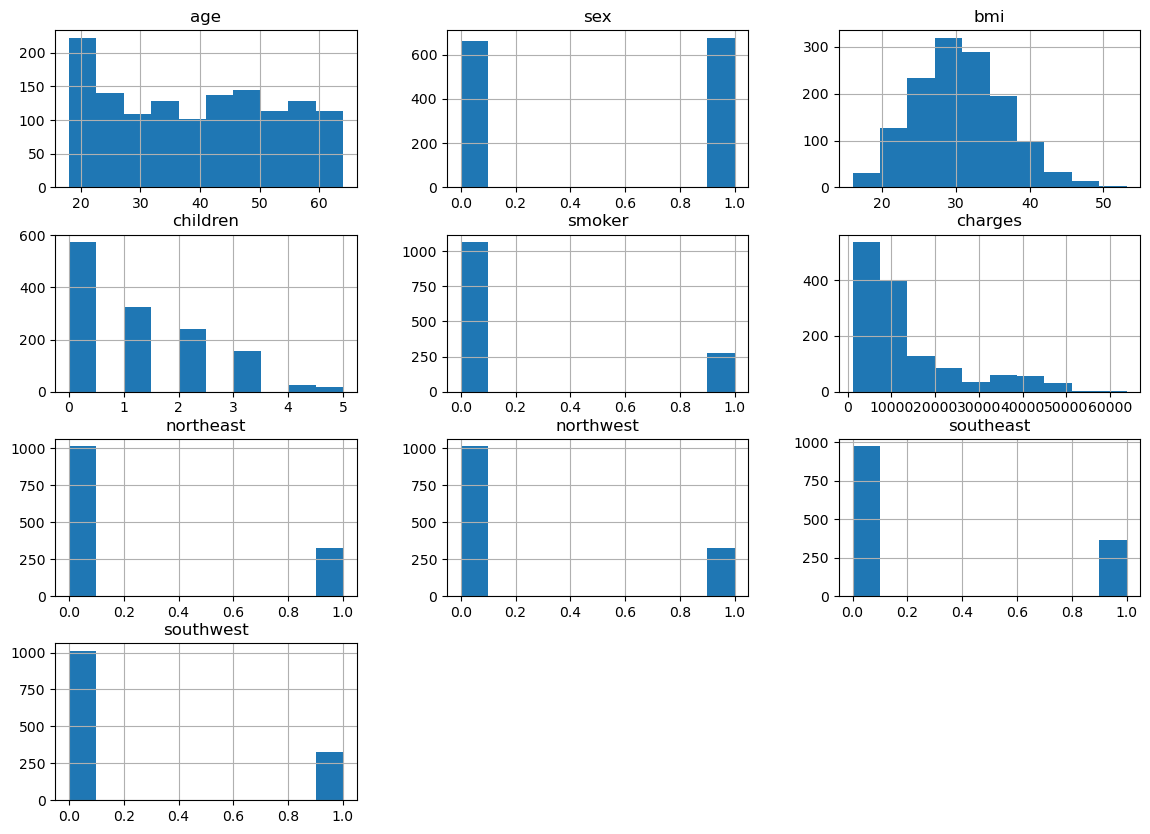

In [17]:
df.hist(figsize=(14,10))

***information about the dataset like datatypes of each column, total number rows, total number of columns and the memory***

In [18]:
print (df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        1338 non-null   int64  
 1   sex        1338 non-null   int64  
 2   bmi        1338 non-null   float64
 3   children   1338 non-null   int64  
 4   smoker     1338 non-null   int64  
 5   charges    1338 non-null   float64
 6   northeast  1338 non-null   int64  
 7   northwest  1338 non-null   int64  
 8   southeast  1338 non-null   int64  
 9   southwest  1338 non-null   int64  
dtypes: float64(2), int64(8)
memory usage: 104.7 KB
None


***checking the correlations***

<Axes: >

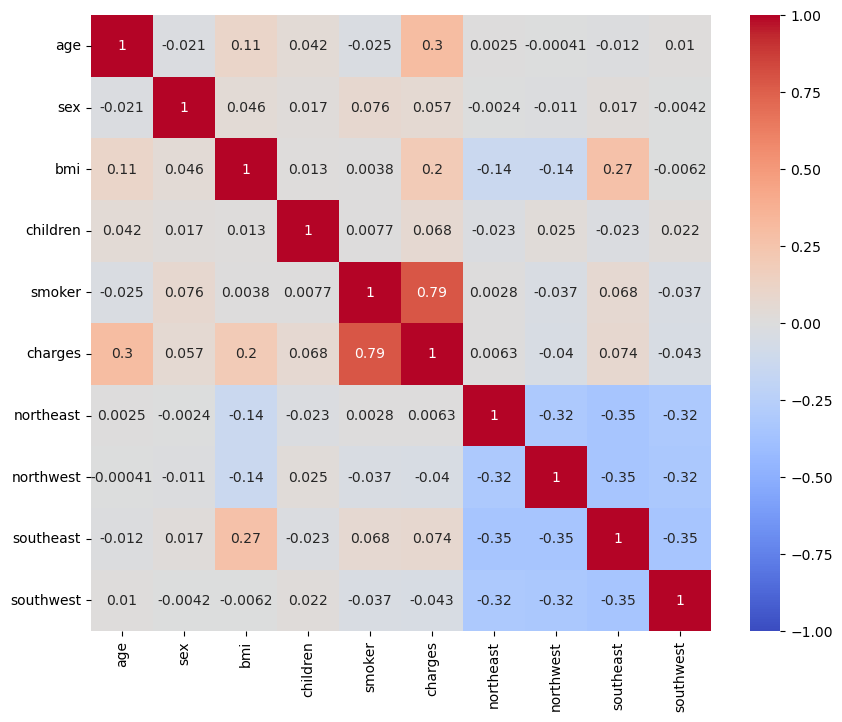

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)

***Checking the missing values in the dataset***

In [24]:
print(df.isnull().sum())

age          0
sex          0
bmi          0
children     0
smoker       0
charges      0
northeast    0
northwest    0
southeast    0
southwest    0
dtype: int64


***Cheching the overvall statistics of the dataset***

In [25]:
print(df.describe(include='all'))

               age          sex          bmi     children       smoker  \
count  1338.000000  1338.000000  1338.000000  1338.000000  1338.000000   
mean     39.207025     0.505232    30.663397     1.094918     0.204783   
std      14.049960     0.500160     6.098187     1.205493     0.403694   
min      18.000000     0.000000    15.960000     0.000000     0.000000   
25%      27.000000     0.000000    26.296250     0.000000     0.000000   
50%      39.000000     1.000000    30.400000     1.000000     0.000000   
75%      51.000000     1.000000    34.693750     2.000000     0.000000   
max      64.000000     1.000000    53.130000     5.000000     1.000000   

            charges    northeast    northwest    southeast    southwest  
count   1338.000000  1338.000000  1338.000000  1338.000000  1338.000000  
mean   13270.422265     0.242152     0.242900     0.272048     0.242900  
std    12110.011237     0.428546     0.428995     0.445181     0.428995  
min     1121.873900     0.000000     

***Training and spliting text***

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2, random_state=42)

In [32]:
y_train

560      9193.83850
1285     8534.67180
1142    27117.99378
969      8596.82780
486     12475.35130
           ...     
1095     4561.18850
1130     8582.30230
1294    11931.12525
860     46113.51100
1126    10214.63600
Name: charges, Length: 1070, dtype: float64

***importing the models***

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

***Training the model***

In [34]:
import numpy as np

print(np.isnan(x_train).sum())
print(np.isnan(y_train).sum())

age          0
sex          0
bmi          0
children     0
smoker       0
northeast    0
northwest    0
southeast    0
southwest    0
dtype: int64
0


In [35]:
x_train = x_train.fillna(x_train.mean())

x_test = x_test.fillna(x_test.mean())

In [36]:

x_train = x_train.dropna()
y_train = y_train.loc[x_train.index]

In [37]:
print(x_train.shape)

(1070, 9)


In [38]:
LR = LinearRegression()
LR.fit(x_train,y_train)
svm = SVR()
svm.fit(x_train,y_train)
RFR = RandomForestRegressor()
RFR.fit(x_train,y_train)
GBR = GradientBoostingRegressor()
GBR.fit(x_train,y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


***Perfoming prediction on the dataset***

In [40]:
pd.DataFrame

pandas.core.frame.DataFrame

In [41]:
y_pred1 = LR.predict(x_test)
y_pred2 = svm.predict(x_test)
y_pred3 = RFR.predict(x_test)
y_pred4 = GBR.predict(x_test)

df1 = pd.DataFrame({'Actual':y_test,'LR':y_pred1,'svm':y_pred2,'RFR':y_pred3,'GBR':y_pred1,})

In [43]:
df1

,Actual,LR,svm,RFR,GBR
764,9095.06825,8969.550274,9551.593540,9894.138081,8969.550274
887,5272.17580,7068.747443,9502.800561,4981.706060,7068.747443
890,29330.98315,36858.410912,9642.025300,28297.202495,36858.410912
1293,9301.89355,9454.678501,9557.540740,11043.965548,9454.678501
259,33750.29180,26973.173457,9435.649390,34861.637109,26973.173457
...,...,...,...,...,...
109,47055.53210,39061.500932,9641.935554,47059.502339,39061.500932
575,12222.89830,11761.499198,9619.987322,12542.344821,11761.499198
535,6067.12675,7687.563632,9512.992798,6368.406653,7687.563632
543,63770.42801,40920.291512,9602.766328,46900.307235,40920.291512


Text(0.5, 1.0, 'prediction VS Truth')

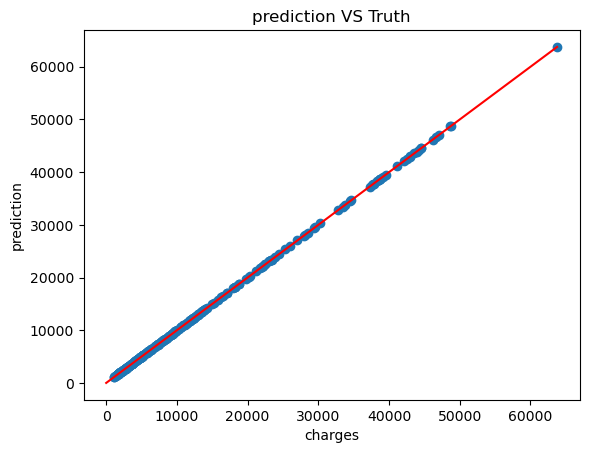

In [51]:
import numpy as np

plt.scatter(y_test, y_test)
plt.plot(np.linspace(0, max(y_test)), np.linspace(0, max(y_test)), color='red')
plt.xlabel('charges')
plt.ylabel('prediction')
plt.title('prediction VS Truth')

***Feature Importances***

In [56]:

feature_importances = sorted(
    zip(model.feature_names_in_, model.feature_importances_),  
    key=lambda x: x[1], 
    reverse=True         
)

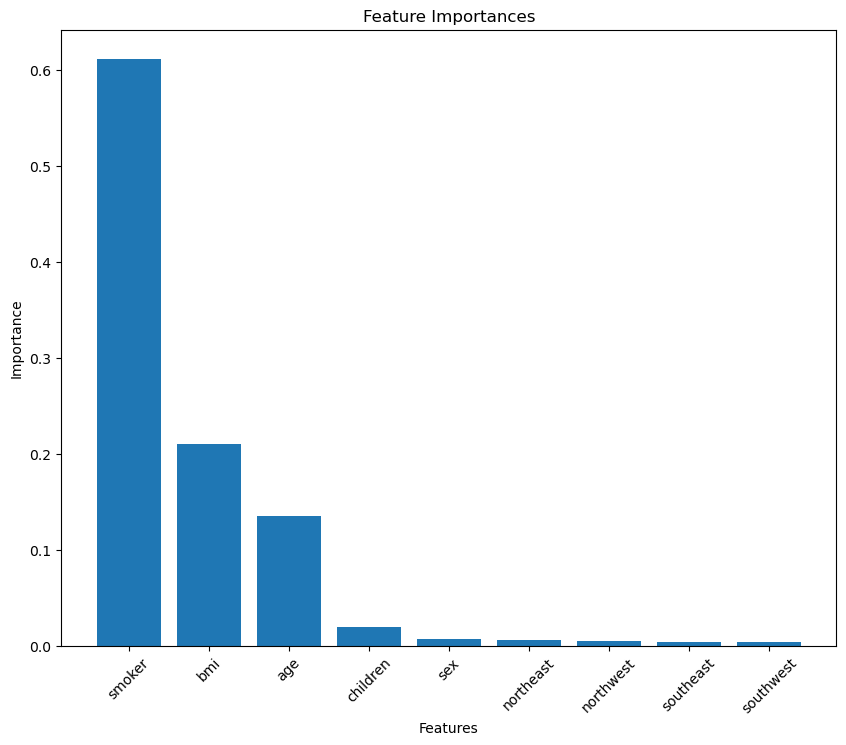

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.bar([x[0] for x in feature_importances], [x[1] for x in feature_importances])
plt.title('Feature Importances')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.show()

***Hyparameters***

In [73]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 2, 5],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt']
}

model = RandomForestRegressor(n_jobs=-1)

grid_search = GridSearchCV(model, param_grid=param_grid, cv=5)

In [74]:
import sklearn
print(sklearn.__version__)

1.7.2


In [75]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
print(rf.get_params().keys())

dict_keys(['bootstrap', 'ccp_alpha', 'criterion', 'max_depth', 'max_features', 'max_leaf_nodes', 'max_samples', 'min_impurity_decrease', 'min_samples_leaf', 'min_samples_split', 'min_weight_fraction_leaf', 'monotonic_cst', 'n_estimators', 'n_jobs', 'oob_score', 'random_state', 'verbose', 'warm_start'])


In [78]:
  grid_search.fit(x_train, y_train)

C:\Users\mosim\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
90 fits failed out of a total of 180.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
90 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\mosim\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\mosim\anaconda3\Lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\Users\mosim\anaconda3\Lib\site-packages\sklearn\base.py", line 471, in _validate_params
   

,estimator,RandomForestR...sor(n_jobs=-1)
,param_grid,"{'max_depth': [None, 2, ...], 'max_features': ['auto', 'sqrt'], 'min_samples_leaf': [1, 2, ...], 'n_estimators': [100, 200]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [79]:
print(grid_search.best_params_)

{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 200}


In [80]:
model = grid_search.best_estimator_

In [81]:
model

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [82]:
model.score(x_test, y_test)

0.8684627853615601

In [83]:
y_pred = model.predict(x_test)

In [85]:
rmse= root_mean_squared_error(y_test, y_pred)

In [86]:
rmse

4518.95847696999

In [87]:
mae = mean_absolute_error(y_test, y_pred)

In [88]:
mae

2662.6237784169844

Text(0.5, 1.0, 'prediction VS Truth')

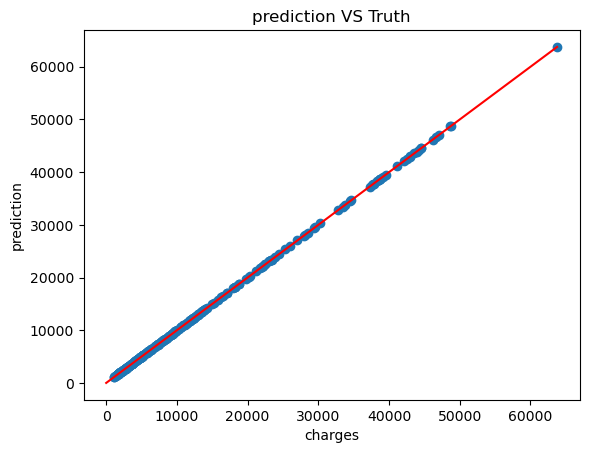

In [89]:
import numpy as np

plt.scatter(y_test, y_test)
plt.plot(np.linspace(0, max(y_test)), np.linspace(0, max(y_test)), color='red')
plt.xlabel('charges')
plt.ylabel('prediction')
plt.title('prediction VS Truth')

***Compering the perfomane of the value***

In [90]:
import matplotlib.pyplot as plt

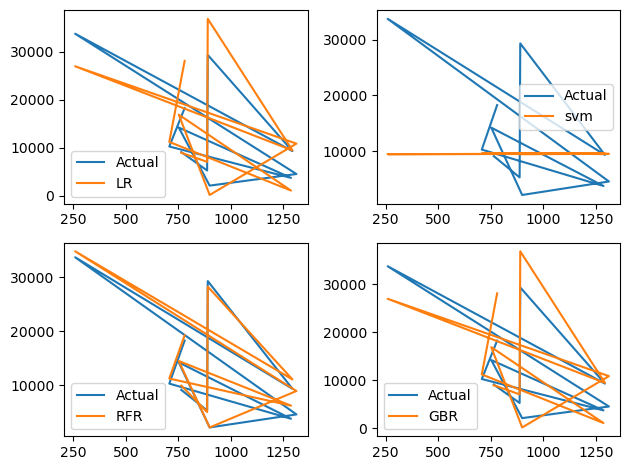

In [91]:
plt.subplot(221)
plt.plot(df1['Actual'].iloc[0:11],label='Actual')
plt.plot(df1['LR'].iloc[0:11],label="LR")
plt.legend()

plt.subplot(222)
plt.plot(df1['Actual'].iloc[0:11],label='Actual')
plt.plot(df1['svm'].iloc[0:11],label="svm")
plt.legend()

plt.subplot(223)
plt.plot(df1['Actual'].iloc[0:11],label='Actual')
plt.plot(df1['RFR'].iloc[0:11],label="RFR")
plt.legend()

plt.subplot(224)
plt.plot(df1['Actual'].iloc[0:11],label='Actual')
plt.plot(df1['GBR'].iloc[0:11],label="GBR")

plt.tight_layout()
plt.legend()

***Evaluating the model***

In [92]:
from sklearn import metrics

In [93]:
score1 = metrics.r2_score(y_test,y_pred1)
score2 = metrics.r2_score(y_test,y_pred2)
score3 = metrics.r2_score(y_test,y_pred3)
score4 = metrics.r2_score(y_test,y_pred4)

In [94]:
print(score1,score2,score3,score4,)

0.7835929767120723 -0.07245515281828974 0.8614345500175159 0.8795925395545199


In [95]:
s1 = metrics.mean_absolute_error(y_test,y_pred1)
s2 = metrics.mean_absolute_error(y_test,y_pred2)
s3 = metrics.mean_absolute_error(y_test,y_pred3)
s4 = metrics.mean_absolute_error(y_test,y_pred4)

In [96]:
print(s1,s2,s3,s4)

4181.194473753641 8597.6930697437 2527.4519464303794 2398.3120112045676
